# 05 — Land cover & soils reclassification → URH (lower-Magdalena prototype)

**Goal.** Turn the two raw layers (ESA WorldCover land cover + IGAC soils) into the two inputs the **URH** needs, by
reclassifying each into a few **hydrological classes**, aligning them to the DEM grid, and crossing them — the
real-data version of notebook `02_urh`.

**Scope — read this before quoting any number below.** This notebook runs on `cop30_dem.tif`, which covers only the
**lower-Magdalena box** (lon −75.4001…−73.7001, lat 8.2001…11.3001; 11,160 × 6,120 cells at 1 arc-second ≈ 30 m) —
*not* the 257,097 km² basin. It is a **method prototype**, and its box is `docs/08`'s pilot box, which that doc's own banner marks obsolete; the locked study domain is `Xmin -77.0, Xmax -72.3, Ymin 1.4, Ymax 11.4` (`docs/15`). The **production URH** that feeds the model is built
basin-wide on the 8,672-minibacia grid by `notebooks/08_urh.ipynb` + `src/build_soil_layer.py`, and keys soils on a
**texture family** parsed from the IGAC soil descriptions rather than the landscape proxy grouped here. No other
notebook reads this notebook's rasters, but `src/build_data_final.py` does: it routes `landcover_hydro_30m.tif` into the
`data_Final/03_landcover/processed` delivery bundle, and `docs/59` s5.1 records R2's `config/data_sources.yaml` naming
*the 30 m landcover_hydro product in data_Final*. Treat its numbers as illustrative, and notebook 08/09 as
authoritative.

**Inputs**

| Path | What |
|---|---|
| `../data/processed/cop30_dem.tif` | target grid, CRS and extent (notebook 04) |
| `../data/raw/landcover/*.zip` | ESA WorldCover 10 m v200, epoch 2021 (Terrascope download) |
| `../data/raw/soils/suelos_<dept>.gpkg` | IGAC departmental soil maps (`src/download_igac_soils.py`) |

**Outputs** — all uint rasters on the DEM grid, written to `../data/processed/`

| Path | What |
|---|---|
| `landcover_hydro_30m.tif` | uint8, 8 hydrological land-cover classes |
| `soils_hydro_30m.tif` | uint8, 9 IGAC landscape groups |
| `urh_30m.tif` | uint16, the crossed URH id |

> Requires `numpy`, `pandas`, `rasterio`, `geopandas`, `matplotlib`. Run from the `notebooks/` folder.
> Heavy: it reprojects 10 m land cover and rasterises ~33k soil polygons onto 68.3 M cells. Minutes, not seconds.
>
> **Every number quoted in the prose below is printed by a cell**, deliberately: hard-coded figures in markdown go
> stale silently, which is how this notebook came to advertise counts from a superseded input.

In [1]:
import glob, os, re, shutil, tempfile, zipfile
import numpy as np, pandas as pd, geopandas as gpd
import rasterio, rasterio.warp                      # rasterio.warp must be imported explicitly
from rasterio.enums import Resampling
from rasterio.features import rasterize
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches, matplotlib.pyplot as plt

RAW  = "../data/raw"
PROC = "../data/processed"
os.makedirs(PROC, exist_ok=True)
DEM_TIF   = os.path.join(PROC, "cop30_dem.tif")   # produced by notebook 04
SOILS_DIR = os.path.join(RAW,  "soils")           # IGAC, src/download_igac_soils.py
LC_DIR    = os.path.join(RAW,  "landcover")       # ESA WorldCover archive (Terrascope)

# La Guajira drains to the Caribbean, not the Magdalena-Cauca. Same exclusion as
# src/build_soil_layer.py, so this notebook and the production layer agree on the domain.
SKIP_DEPTS = {"laguajira"}

assert os.path.exists(DEM_TIF), f"missing {DEM_TIF} - run notebook 04 first"
with rasterio.open(DEM_TIF) as _d:
    DEM_SHAPE   = (_d.height, _d.width)
    DEM_TR      = _d.transform
    DEM_CRS     = _d.crs
    DEM_BOUNDS  = _d.bounds
    DEM_PROFILE = _d.profile
EXTENT = [DEM_BOUNDS.left, DEM_BOUNDS.right, DEM_BOUNDS.bottom, DEM_BOUNDS.top]
print(f"DEM grid {DEM_SHAPE[0]} x {DEM_SHAPE[1]} cells @ {DEM_TR.a:.7f} deg ({DEM_CRS})")
print(f"box      lon {DEM_BOUNDS.left:.4f} .. {DEM_BOUNDS.right:.4f}   "
      f"lat {DEM_BOUNDS.bottom:.4f} .. {DEM_BOUNDS.top:.4f}")

# ---- class names + palettes -------------------------------------------------------------
# The land-cover ids and colours are IDENTICAL to notebook 08 on purpose: the same class
# wears the same colour in the prototype and in the production URH.
LC_NAMES = {1:"Forest", 2:"Shrub", 3:"Grassland", 4:"Cropland",
            5:"Urban",  6:"Bare",  7:"Water",     8:"Wetland"}
LC_COL   = {1:'#1a7f37', 2:'#8FB06B', 3:'#C9D77E', 4:'#E8C766',
            5:'#B0412B', 6:'#B7A99A', 7:'#3D6FB0', 8:'#5FA8A0'}

# Landscape groups are ORDERED by relief energy (1 rugged -> 6 flat), so ids 1-6 get a
# monotone hypsometric brown->tan ramp (OKLab L 0.33 -> 0.92, strictly increasing) rather
# than 6 arbitrary hues. Water/Urban reuse notebook 08's blue/brick; Rock/Other is the
# reserved neutral for the catch-all bucket.
SOIL_NAMES = {1:"Mountain", 2:"Hills", 3:"Piedmont", 4:"Plateau", 5:"Plain",
              6:"Valley",   7:"Water", 8:"Urban",    9:"Rock/Other"}
SOIL_COL   = {1:'#4A2E17', 2:'#7A4E28', 3:'#A5713C', 4:'#C69A5F', 5:'#E0C48F',
              6:'#F2E1BE', 7:'#3D6FB0', 8:'#B0412B', 9:'#9AA0A6'}

N_LC = 8          # URH id = (soil_id - 1) * N_LC + lc_id
DEC  = 4          # display decimation for the maps (nearest-neighbour, plotting only)
CHUNK = 8 << 20   # >=4 MB reads: Defender makes small-buffer I/O ~30x slower (CLAUDE.md)


def save_raster(arr, name, dtype):
    """Write via a temp file, then copy in.

    rasterio's 'w' mode needs to unlink-then-create, which this data mount refuses, so a
    direct overwrite fails on the SECOND run. Same workaround as src/build_soil_layer.py.
    """
    prof = dict(DEM_PROFILE)
    prof.update(count=1, dtype=dtype, nodata=0, compress="lzw")
    tmp = os.path.join(tempfile.gettempdir(), name)
    with rasterio.open(tmp, "w", **prof) as d:
        d.write(arr.astype(dtype), 1)
    dst = os.path.join(PROC, name)
    shutil.copyfile(tmp, dst)
    os.remove(tmp)
    print(f"wrote {dst}  ({os.path.getsize(dst)/1e6:.1f} MB)")


def share_table(a, names, title):
    """Percent of *classified* cells per class, printed. Also returned for figure labels."""
    cls = a[a > 0]
    sh = {k: 100.0 * float(np.mean(cls == k)) for k in names if (a == k).any()}
    print(title)
    for k, v in sorted(sh.items(), key=lambda kv: -kv[1]):
        print(f"  {names[k]:<11} {v:5.1f}%")
    return sh

DEM grid 11160 x 6120 cells @ 0.0002778 deg (EPSG:4326)
box      lon -75.4001 .. -73.7001   lat 8.2001 .. 11.3001


## 1. Land cover → hydrological classes

ESA WorldCover has 11 codes. We collapse them into the classes that matter for the water balance and the MUSLE cover
factor. Water and wetland are kept separate because they behave very differently hydrologically.

Two things the first version of this cell got wrong, both now guarded:

- **The archive is found by glob, not by a fixed name.** Terrascope names each download after its request id
  (`terrascope_download_<timestamp>.zip`), so the hard-coded `worldcover_2021.zip` stopped existing the same day it was
  written and the cell would raise `FileNotFoundError` on any re-run.
- **The tiles must actually tile the box, and that is now asserted.** WorldCover ships 3° × 3° tiles named by their SW
  corner. A missing tile does not raise — it silently leaves a nodata strip, and because every share statistic is taken
  over classified cells only, the strip disappears from the result instead of showing up as an error. That is exactly
  what happened: two of the four tiles overlapping this box were absent, blanking 1,440 of 6,120 columns (23.5 % of the
  box, the whole strip west of lon −75.0) and quietly biasing the class shares this notebook used to print.

In [2]:
# WorldCover raw code -> hydrological class id (60/70/100 all collapse to Bare; 90/95 to Wetland)
LC_MAP = {10:1, 20:2, 30:3, 40:4, 50:5, 60:6, 70:6, 80:7, 90:8, 95:8, 100:6}

zips = sorted(glob.glob(os.path.join(LC_DIR, "*.zip")))
assert zips, f"no WorldCover .zip found in {LC_DIR}"
LC_ZIP = zips[-1]                                  # newest download wins
print("archive:", os.path.basename(LC_ZIP))


def tile_bounds(name):
    """ESA WorldCover tiles are 3x3 deg, named by their SW corner (e.g. N06W075)."""
    m = re.search(r"([NS])(\d{2})([EW])(\d{3})", name)
    assert m, f"cannot parse a tile corner out of {name!r}"
    lat = int(m.group(2)) * (1 if m.group(1) == "N" else -1)
    lon = int(m.group(4)) * (1 if m.group(3) == "E" else -1)
    return lon, lat, lon + 3, lat + 3


def overlaps_dem(b):
    return not (b[2] <= DEM_BOUNDS.left or b[0] >= DEM_BOUNDS.right
                or b[3] <= DEM_BOUNDS.bottom or b[1] >= DEM_BOUNDS.top)


lc_dir = os.path.join(PROC, "worldcover")
os.makedirs(lc_dir, exist_ok=True)
tiles = []
with zipfile.ZipFile(LC_ZIP) as zf:
    entries = sorted(n for n in zf.namelist() if n.endswith("_Map.tif"))
    print(f"{len(entries)} Map tiles in the archive; keeping those overlapping the DEM box")
    for n in entries:
        base = os.path.basename(n)                 # entries are nested WORLDCOVER/.../<tile>/
        if not overlaps_dem(tile_bounds(base)):
            continue
        out = os.path.join(lc_dir, base)
        if not os.path.exists(out):
            with zf.open(n) as s, open(out, "wb") as d:
                shutil.copyfileobj(s, d, CHUNK)
            print("  extracted", base)
        tiles.append(out)
assert tiles, "no WorldCover tile overlaps the DEM box - wrong archive?"
for t in tiles:
    print("  tile", os.path.basename(t), "->", tile_bounds(os.path.basename(t)))

# ---- the guard: do the kept tiles cover the whole box? ----------------------------------
gx = np.linspace(DEM_BOUNDS.left, DEM_BOUNDS.right, 400)[1:-1]
gy = np.linspace(DEM_BOUNDS.bottom, DEM_BOUNDS.top, 400)[1:-1]
GX, GY = np.meshgrid(gx, gy)
cov = np.zeros(GX.shape, bool)
for t in tiles:
    x0, y0, x1, y1 = tile_bounds(os.path.basename(t))
    cov |= (GX >= x0) & (GX < x1) & (GY >= y0) & (GY < y1)
print(f"tile coverage of the DEM box: {100*cov.mean():.2f}% (398x398 sample)")
assert cov.all(), (f"WorldCover tiles leave {100*(~cov).mean():.1f}% of the box uncovered - "
                   "a missing tile would silently become a nodata strip")

archive: terrascope_download_20260728_153218.zip
8 Map tiles in the archive; keeping those overlapping the DEM box


  extracted ESA_WorldCover_10m_2021_v200_N06W078_Map.tif
  extracted ESA_WorldCover_10m_2021_v200_N09W078_Map.tif
  tile ESA_WorldCover_10m_2021_v200_N06W075_Map.tif -> (-75, 6, -72, 9)
  tile ESA_WorldCover_10m_2021_v200_N06W078_Map.tif -> (-78, 6, -75, 9)
  tile ESA_WorldCover_10m_2021_v200_N09W075_Map.tif -> (-75, 9, -72, 12)
  tile ESA_WorldCover_10m_2021_v200_N09W078_Map.tif -> (-78, 9, -75, 12)
tile coverage of the DEM box: 100.00% (398x398 sample)


We resample the 10 m land cover onto the **DEM grid** with *majority* (`Resampling.mode`) resampling — the correct
choice for categorical data, where averaging is meaningless — then reclassify to the hydrological ids and save an
aligned raster.

The cell reports the cumulative coverage after each tile and, as a regression guard on the nodata-strip bug above,
asserts that **no DEM column** comes out essentially empty. (Scattered unclassified cells are expected: the box
includes open Caribbean sea. A *fully* empty column is not.)

  + ESA_WorldCover_10m_2021_v200_N06W075_Map.tif  cumulative coverage  19.7%


  + ESA_WorldCover_10m_2021_v200_N06W078_Map.tif  cumulative coverage  25.8%


  + ESA_WorldCover_10m_2021_v200_N09W075_Map.tif  cumulative coverage  82.5%


  + ESA_WorldCover_10m_2021_v200_N09W078_Map.tif  cumulative coverage  99.2%


WorldCover codes seen but not in LC_MAP: none


unclassified cells 0.75%   fully-empty columns 0


wrote ../data/processed\landcover_hydro_30m.tif  (5.3 MB)



Land-cover hydro classes (% of classified cells):
  Grassland    45.3%
  Forest       31.9%
  Water        12.1%
  Wetland       8.5%
  Cropland      0.8%
  Urban         0.6%
  Shrub         0.5%
  Bare          0.3%


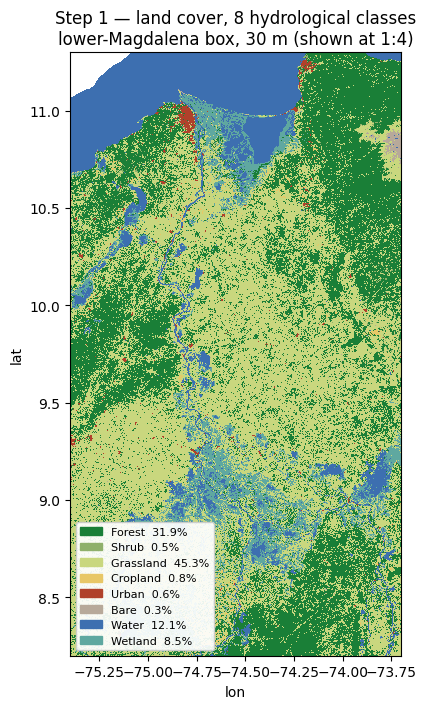

In [3]:
raw = np.zeros(DEM_SHAPE, "uint8")
for tp in tiles:
    with rasterio.open(tp) as src:
        tmp = np.zeros(DEM_SHAPE, "uint8")
        rasterio.warp.reproject(
            source=rasterio.band(src, 1), destination=tmp,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=DEM_TR, dst_crs=DEM_CRS, resampling=Resampling.mode)
    raw = np.where((raw == 0) & (tmp > 0), tmp, raw)      # first tile to claim a cell wins
    print(f"  + {os.path.basename(tp):<45} cumulative coverage {100*np.mean(raw>0):5.1f}%")
del tmp

lc = np.zeros_like(raw)
for code, hid in LC_MAP.items():
    lc[raw == code] = hid
unmapped = np.unique(raw[(raw > 0) & (lc == 0)]).tolist()
print("WorldCover codes seen but not in LC_MAP:", unmapped or "none")

empty_cols = int((( lc == 0).mean(axis=0) > 0.999).sum())
print(f"unclassified cells {100*np.mean(lc==0):.2f}%   fully-empty columns {empty_cols}")
assert empty_cols == 0, f"{empty_cols} DEM columns have no land cover at all - missing tile"
del raw

save_raster(lc, "landcover_hydro_30m.tif", "uint8")
sh = share_table(lc, LC_NAMES, "\nLand-cover hydro classes (% of classified cells):")

fig, ax = plt.subplots(figsize=(5.4, 7.2))
d = lc[::DEC, ::DEC]
ax.imshow(np.where(d > 0, d, np.nan), extent=EXTENT, interpolation='none',
          cmap=ListedColormap([LC_COL[i] for i in range(1, 9)]), vmin=.5, vmax=8.5)
ax.legend(handles=[mpatches.Patch(color=LC_COL[i], label=f"{LC_NAMES[i]}  {sh.get(i, 0):.1f}%")
                   for i in range(1, 9)], loc='lower left', fontsize=8, framealpha=.92)
ax.set_title(f"Step 1 — land cover, 8 hydrological classes\nlower-Magdalena box, 30 m (shown at 1:{DEC})")
ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.tight_layout(); plt.show()

## 2. Soils → landscape/hydrological groups (first pass)

The IGAC soil maps are read **per department, straight from `../data/raw/soils/`** — the same primary source
`src/build_soil_layer.py` uses.

*This replaced a read of `data/processed/soils_magdalena_merged_4326.gpkg`, which broke this notebook. That merged file
is (a) unreadable — a stale SQLite hot journal sits beside it, so any read-only open fails with "attempt to write a
readonly database" — and (b) stale: it holds only the 8 departments that had been downloaded when it was built,
including out-of-basin La Guajira and excluding the entire Andean upper basin (Huila, Tolima, Cauca, Valle del Cauca,
Cundinamarca, Boyacá, Santander, Caldas, Quindío, Risaralda, Norte de Santander). Reading the departments directly
removes the dependency on that intermediate altogether.*

Two traps handled in the cell below:

- **Missing CRS.** Several departmental exports carry no CRS at all. They are MAGNA-SIRGAS / Origen-Nacional
  (**EPSG:9377**), in metres. Rasterising them against an EPSG:4326 transform without
  `set_crs(9377).to_crs(4326)` yields an *empty* raster rather than an error.
- **La Guajira excluded** as outside the Magdalena–Cauca drainage, matching `src/build_soil_layer.py`.

Each polygon's `PAISAJE` (landscape) field is harmonised into a handful of **landscape groups** — a defensible *first
pass* that proxies hydrological behaviour: steep mountains shed water fast, flat plains and valleys store and
infiltrate it. The spellings that fall through to the `Rock/Other` catch-all are **printed**, so the bucket can be
audited instead of trusted.

> **Caveat — superseded downstream.** This is a landscape (geomorphology) proxy, not a Hydrologic Soil Group. The
> refinement the first version of this notebook flagged for the advisor has since been done — and *not* with
> SoilGrids. The production pipeline parses a **texture family** (Coarse/Medium/Fine) plus **effective depth** and
> **drainage class** out of the IGAC free-text soil descriptions (`src/build_soil_layer.py`), and notebook 09 turns
> those into MGB's `Wm` and the MUSLE erodibility `K`. SoilGrids was rejected as the primary source. **This notebook does not read SoilGrids**, so the sentence that follows is
> qualitative and un-re-derived here, and three unreconciled versions of it exist: this one; `docs/38` s4.1's transcription
> from `Explanation_script_MGB_SA_Magdalena.pdf` (49 % agreement with IGAC, ~99 % Fine, Coarse 19 %, Medium 32 %), which
> `docs/38` says are *transcribed, not re-derived* and must be re-measured from this notebook before being quoted in a
> report; and `docs/59` s5.1's note from R2's `config/data_sources.yaml` (SoilGrids classes 95 % of the basin as Fine
> against IGAC's 38 %) — an independent *implementation*, not independent data (`docs/59`). Quote none of the three as
> this notebook's measurement. Its own claim is only that SoilGrids collapses the
> great majority of the basin into a single "Fine" class — and is kept only as a gap-fill where IGAC has no coverage.
> For anything quantitative, use notebooks 08 and 09.

In [4]:
def group_paisaje(s):
    """IGAC PAISAJE free text -> (landscape group id, name). Ordered 1 rugged .. 6 flat."""
    s = str(s).upper()
    if "MONTAÑA" in s:                            return (1, "Mountain")
    if "LOMA" in s or "LOMER" in s:               return (2, "Hills")
    if "PIEDEMONTE" in s or "PIE DE MONTE" in s:  return (3, "Piedmont")
    if "ALTIPLANICIE" in s:                       return (4, "Plateau")
    if "PLANICIE" in s:                           return (5, "Plain")
    if "VALLE" in s:                              return (6, "Valley")
    if "CUERPO" in s:                             return (7, "Water")
    if "URBAN" in s:                              return (8, "Urban")
    if "ROCOSO" in s or "MINERA" in s:            return (9, "Rock/Other")
    return (9, "Rock/Other")


paths = [p for p in sorted(glob.glob(os.path.join(SOILS_DIR, "suelos_*.gpkg")))
         if os.path.basename(p)[7:-5] not in SKIP_DEPTS]
assert paths, f"no suelos_*.gpkg in {SOILS_DIR} - run src/download_igac_soils.py"
print(f"{len(paths)} in-basin IGAC department maps (excluded: {sorted(SKIP_DEPTS)})\n")

frames = []
for fp in paths:
    dep = os.path.basename(fp)[7:-5]
    g = gpd.read_file(fp)
    src_crs = "none -> assumed EPSG:9377" if g.crs is None else str(g.crs)
    if g.crs is None:
        g = g.set_crs(9377, allow_override=True)   # MAGNA-SIRGAS / Origen-Nacional, metres
    g = g.to_crs(4326)
    assert "PAISAJE" in g.columns, f"{dep}: no PAISAJE column, schema changed"
    frames.append(g[["PAISAJE", "geometry"]].assign(DEPTO=dep))
    print(f"  {dep:<18} {len(g):>6} polygons   crs {src_crs}")

soils = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=4326)
soils["SOIL_ID"] = soils["PAISAJE"].map(lambda s: group_paisaje(s)[0])
print(f"\nmerged: {len(soils):,} polygons, {soils['PAISAJE'].nunique()} distinct PAISAJE spellings")

print("\nSoil landscape groups (polygon counts, all 18 in-basin departments):")
print(soils["SOIL_ID"].map(SOIL_NAMES).value_counts().to_string())

other = sorted(soils.loc[soils.SOIL_ID == 9, "PAISAJE"].dropna().astype(str).unique().tolist())
print(f"\nspellings routed to the Rock/Other catch-all ({len(other)}) - audit these:")
for o in other:
    print("   ", o)

18 in-basin IGAC department maps (excluded: ['laguajira'])



  antioquia            6250 polygons   crs none -> assumed EPSG:9377
  atlantico             576 polygons   crs none -> assumed EPSG:9377


  bolivar              1583 polygons   crs none -> assumed EPSG:9377
  boyaca               1208 polygons   crs EPSG:4326
  caldas                494 polygons   crs EPSG:4326


  cauca                1705 polygons   crs EPSG:4326


  cesar                1682 polygons   crs none -> assumed EPSG:9377


  cordoba              3086 polygons   crs none -> assumed EPSG:9377
  cundinamarca         2115 polygons   crs EPSG:4326
  huila                1402 polygons   crs EPSG:4326


  magdalena            2483 polygons   crs none -> assumed EPSG:9377
  nortedesantander     1760 polygons   crs EPSG:4326
  quindio               148 polygons   crs EPSG:4326
  risaralda             157 polygons   crs EPSG:4326


  santander            2132 polygons   crs EPSG:4326
  sucre                 732 polygons   crs none -> assumed EPSG:9377
  tolima               1056 polygons   crs EPSG:4326


  valledelcauca        4348 polygons   crs EPSG:4326

merged: 32,917 polygons, 57 distinct PAISAJE spellings

Soil landscape groups (polygon counts, all 18 in-basin departments):
SOIL_ID
Mountain      11228
Hills          5395
Water          4001
Piedmont       3799
Plain          3686
Valley         2464
Urban          1675
Plateau         442
Rock/Other      227

spellings routed to the Rock/Other catch-all (13) - audit these:
    CA
    Colina
    Fosas mineras
    Misceláneo erosionado
    Misceláneo rocoso
    N/A
    Nieves perpetuas
    Nieves temporales
    Pantanos
    Playones
    Tierras misceláneas, con pendientes mayores del 75%, relieve muy escarpado
    VERIFICAR
    ZU


Rasterise the landscape groups onto the DEM grid so soils and land cover share the exact same cells — the alignment
prerequisite from notebook 02 ("everything on the DEM grid").

Note the asymmetry, and do not read past it: the **polygon counts above are basin-wide** (all 18 in-basin
departments), while the **raster below is clipped to the lower-Magdalena box**. Only the departments intersecting that
box contribute cells, so the map's area shares and the table's polygon counts describe different domains.

cells with a soil group inside the DEM box: 89.2%


wrote ../data/processed\soils_hydro_30m.tif  (1.5 MB)



Landscape groups (% of classified cells in the box):
  Hills        31.4%
  Plain        27.1%
  Mountain     16.3%
  Water        10.2%
  Valley        8.3%
  Piedmont      6.1%
  Urban         0.7%
  Rock/Other    0.0%


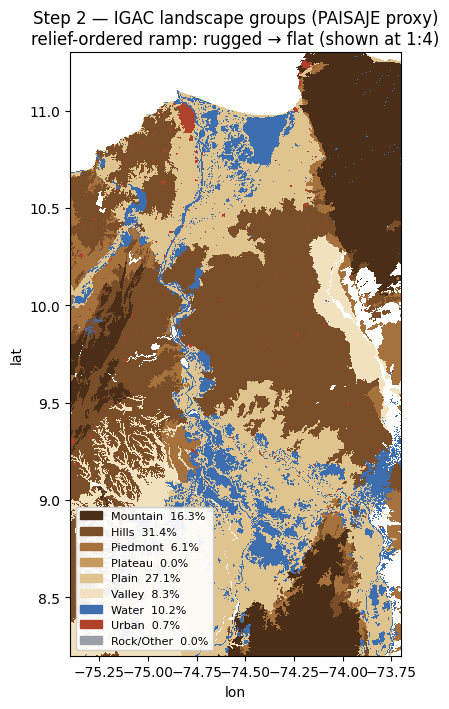

In [5]:
soil_ras = rasterize(((geom, int(sid)) for geom, sid in zip(soils.geometry, soils["SOIL_ID"])),
                    out_shape=DEM_SHAPE, transform=DEM_TR, fill=0, dtype="uint8")
print(f"cells with a soil group inside the DEM box: {100*np.mean(soil_ras>0):.1f}%")
save_raster(soil_ras, "soils_hydro_30m.tif", "uint8")
shs = share_table(soil_ras, SOIL_NAMES, "\nLandscape groups (% of classified cells in the box):")

fig, ax = plt.subplots(figsize=(5.4, 7.2))
d = soil_ras[::DEC, ::DEC]
ax.imshow(np.where(d > 0, d, np.nan), extent=EXTENT, interpolation='none',
          cmap=ListedColormap([SOIL_COL[i] for i in range(1, 10)]), vmin=.5, vmax=9.5)
ax.legend(handles=[mpatches.Patch(color=SOIL_COL[i], label=f"{SOIL_NAMES[i]}  {shs.get(i, 0):.1f}%")
                   for i in range(1, 10)], loc='lower left', fontsize=8, framealpha=.92)
ax.set_title("Step 2 — IGAC landscape groups (PAISAJE proxy)\n"
             f"relief-ordered ramp: rugged → flat (shown at 1:{DEC})")
ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.tight_layout(); plt.show()

## 3. Cross soil × land cover → URH

Exactly notebook 02's index formula, now on the real grid:

$$\text{URH} = (\text{soil\_id}-1)\cdot N_{lc} + \text{lc\_id}$$

Each cell that has **both** a soil group and a land-cover class gets a unique URH id; cells missing either stay 0. A
72-class map cannot be legended honestly, so the composition is shown as a ranked bar chart instead — the same
presentation notebook 08 uses for the basin-wide URH composition.

wrote ../data/processed\urh_30m.tif  (7.9 MB)


cells carrying both layers: 89.2%
distinct URH present: 62 of 72 possible
top 15 URH account for 96.3% of the crossed area


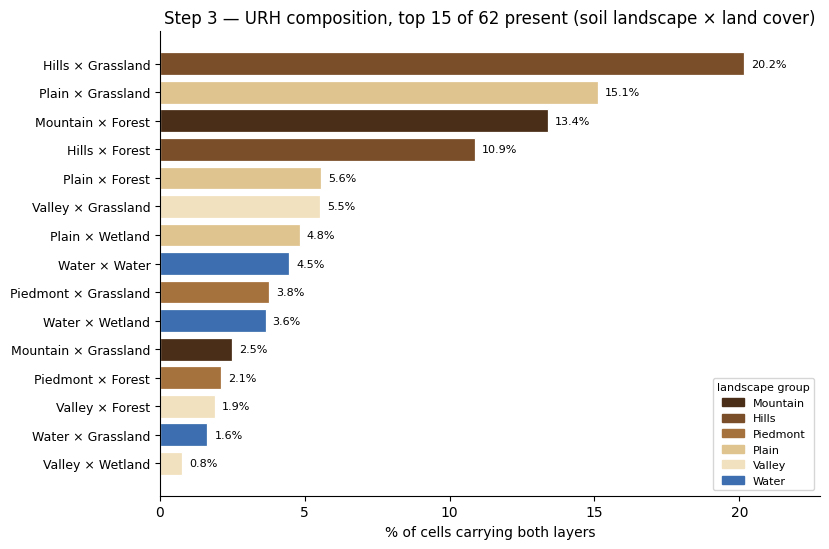

In [6]:
with rasterio.open(os.path.join(PROC, "landcover_hydro_30m.tif")) as s:
    lc = s.read(1)
with rasterio.open(os.path.join(PROC, "soils_hydro_30m.tif")) as s:
    soil = s.read(1)

valid = (lc > 0) & (soil > 0)
urh = np.zeros(DEM_SHAPE, "uint16")
urh[valid] = (soil[valid].astype("uint16") - 1) * N_LC + lc[valid]
save_raster(urh, "urh_30m.tif", "uint16")

ids, cnt = np.unique(urh[urh > 0], return_counts=True)
print(f"cells carrying both layers: {100*valid.mean():.1f}%")
print(f"distinct URH present: {ids.size} of {9*N_LC} possible")

k = min(15, ids.size)
order = np.argsort(-cnt)[:k]
labels = [f"{SOIL_NAMES[(i-1)//N_LC + 1]} × {LC_NAMES[(i-1)%N_LC + 1]}" for i in ids[order]]
vals = 100.0 * cnt[order] / cnt.sum()
cols = [SOIL_COL[(i-1)//N_LC + 1] for i in ids[order]]
print(f"top {k} URH account for {vals.sum():.1f}% of the crossed area")

y = np.arange(k)[::-1]
fig, ax = plt.subplots(figsize=(8.4, 5.6))
ax.barh(y, vals, color=cols, edgecolor='white', linewidth=.9)
for yy, v in zip(y, vals):
    ax.text(v + max(vals)*.012, yy, f"{v:.1f}%", va='center', fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlim(0, max(vals)*1.13)
ax.set_xlabel('% of cells carrying both layers')
ax.set_title(f"Step 3 — URH composition, top {k} of {ids.size} present (soil landscape × land cover)")
groups = sorted({(i-1)//N_LC + 1 for i in ids[order]})
ax.legend(handles=[mpatches.Patch(color=SOIL_COL[g], label=SOIL_NAMES[g]) for g in groups],
          loc='lower right', fontsize=8, title='landscape group', title_fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. What's done, and what's next

**Done here (method, reusable at any extent):**

- `landcover_hydro_30m.tif` — WorldCover reclassified to 8 hydrological classes, on the DEM grid.
- `soils_hydro_30m.tif` — IGAC `PAISAJE` grouped into 9 relief-ordered landscape groups, on the DEM grid.
- `urh_30m.tif` — the crossed URH map.

**Already superseded — go here instead.** This notebook is kept as the derivation of the crossing method; it is not on
the model's critical path.

| Need | Use |
|---|---|
| Basin-wide URH, real domain | `notebooks/08_urh.ipynb` (8,672 minibacias) |
| Soil texture family / depth / drainage | `src/build_soil_layer.py` → `data/processed/soil_*_igac.tif` |
| MGB `Wm` and MUSLE `K` per minibacia | `notebooks/09_soil_parameters.ipynb` → `minibacia_soil_params.csv` |
| Per-minibacia URH fractions `f_{m,u}` | `data/processed/urh_fractions.csv` (notebook 08) |

**Still open — and tracked nowhere else.** Grepped 2026-08-19 against `docs/31` (the open register), `docs/47` O1-O12,
`docs/41` and `docs/37`: neither item below appears in any project register, so this notebook is their only home. Do not
assume someone else is carrying them.

- **Period-matched land cover.** WorldCover epoch 2021 is used to build the workflow, but the runs of interest are
  La Niña 2011 and El Niño 2015–16. IDEAM Corine (~2010–2012) or ESA CCI would be period-matched. *Not resolved.*
- **The `Rock/Other` catch-all.** The cell prints every spelling that lands in it; anything substantive there should
  get its own group.
- **What this notebook structurally cannot answer, recorded so nobody re-opens it.** `docs/59` **X7** asks for a per-code
  histogram of WorldCover codes 60 / 70 / 100 over the basin mask (class 6 is 0.196 % of area but 14.78 % of modelled
  erosion). This notebook cannot supply it: `overlaps_dem()` filters tiles against `DEM_BOUNDS`, i.e. the lower box, so it
  never pulls a tile south of lat 6; and `LC_MAP` collapses 60 / 70 / 100 into id 6 before any histogram could be taken.
  X7 needs a basin-extent rerun with the collapse deferred, not a read of this notebook's output.

---

**Repair log (this notebook was broken and has been fixed — recorded so the failure mode is not repeated):**

| # | Fault | Effect | Fix |
|---|---|---|---|
| 1 | Read `soils_magdalena_merged_4326.gpkg`, beside which a stale SQLite **hot journal** sits | `DataSourceError: attempt to write a readonly database` — notebook died at 4 of 6 code cells | Read the 18 in-basin `data/raw/soils/suelos_*.gpkg` directly |
| 2 | That merged file was an 8-of-19-department subset including out-of-basin La Guajira | Landscape-group counts described the Caribbean lowlands, not the basin | Per-department read + `SKIP_DEPTS` |
| 3 | Hard-coded `worldcover_2021.zip` | File renamed by the next Terrascope download; `FileNotFoundError` on re-run | Glob the archive |
| 4 | Only 2 of 4 overlapping WorldCover tiles present | **1,440 of 6,120 columns silently blank (23.5 %)**; class shares computed on 76.5 % of the box | Tile-footprint filter + coverage assertion + empty-column assertion |
| 5 | `rasterio.open(..., 'w')` overwrite | Fails on the second run (mount forbids unlink-overwrite) | `save_raster()` temp-then-copy |
| 6 | No plotting code at all | 0 figures; nothing to check the rasters against by eye | 3 figures, palettes shared with notebook 08 |
| 7 | `rasterio.warp` used without importing it | Worked only because another import pulled it in | Explicit `import rasterio.warp` |

⚠️ **`data/processed/soils_magdalena_merged_4326.gpkg-journal` was quarantined on 2026-07-28 and is no longer live.** RETIRED / superseded — shown, not quoted as current. What sits on
disk today (checked 2026-08-19) is `soils_magdalena_merged_4326.gpkg-journal.DISABLED` (512 B); the hazard described next
is the record of a hazard already closed, not an outstanding action. Its header was a
valid hot-journal with `nPage = 0`, so the first process that opens the `.gpkg` **writable** (QGIS, `ogr2ogr`, the
`sqlite3` CLI) would have rolled it back and truncated 132 MB of derived data to nothing. The journal is quarantined; do
**not** delete the
pair.

**Correction (2026-08-19) — RETIRED / superseded, shown not quoted as current.** This block used to end *the merged file
has no remaining consumer*. That is wrong, and acting on it would have destroyed evidence. `docs/59` s5.1 lists
`soils.merged_polygons: soils_magdalena_merged_4326.gpkg` among the inputs R2's `config/data_sources.yaml` names
(*present | same filename*), so it is a named cross-implementation provenance artifact; and `src/build_data_final.py`
routes both `soils_magdalena_merged_4326.gpkg` and a bare `soils_magdalena_merged_4326.gpkg-journal` entry into
`data_Final/04_soils/processed`. Keep the `.DISABLED` rename and keep the `.gpkg`.